# CNN From Scratch — Learning to See

## Goal
Build a Convolutional Neural Network from scratch using numpy.
Understand how CNNs learn filters automatically — no hand-crafting.

## Key Questions
- How does a CNN combine convolution, activation, and pooling?
- How do filters change during training?
- How does backpropagation work through a convolutional layer?

## What We Build
A simple CNN: Conv → ReLU → Pool → Flatten → Dense → Output
Trained on a simple binary classification task.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. CNN Building Blocks

In [2]:
def relu(x: np.ndarray) -> np.ndarray:
    """ReLU activation - max(0, x)."""
    return np.maximum(0, x)

def relu_derivative(x: np.ndarray) -> np.ndarray:
    """Derivative of ReLU."""
    return (x > 0).astype(float)

def sigmoid(x: np.ndarray) -> np.ndarray:
    """Sigmoid activation."""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def max_pool2d(feature_map: np.ndarray, pool_size: int = 2) -> np.ndarray:
    """Max pooling - reduces spatial size by pool_size factor."""
    h, w = feature_map.shape
    out_h, out_w = h // pool_size, w // pool_size
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = feature_map[i*pool_size:(i+1)*pool_size,
                                 j*pool_size:(j+1)*pool_size]
            output[i, j] = np.max(region)
    return output

def convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """2D convolution with zero padding."""
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)))
    output = np.zeros((h, w))
    for i in range(h):
        for j in range(w):
            output[i, j] = np.sum(padded[i:i+kh, j:j+kw] * kernel)
    return output

print("Building blocks defined:")
print("- relu, relu_derivative")
print("- sigmoid")
print("- max_pool2d")
print("- convolve2d")

Building blocks defined:
- relu, relu_derivative
- sigmoid
- max_pool2d
- convolve2d


## 2. Create Training Data
Binary classification: horizontal stripes vs vertical stripes.

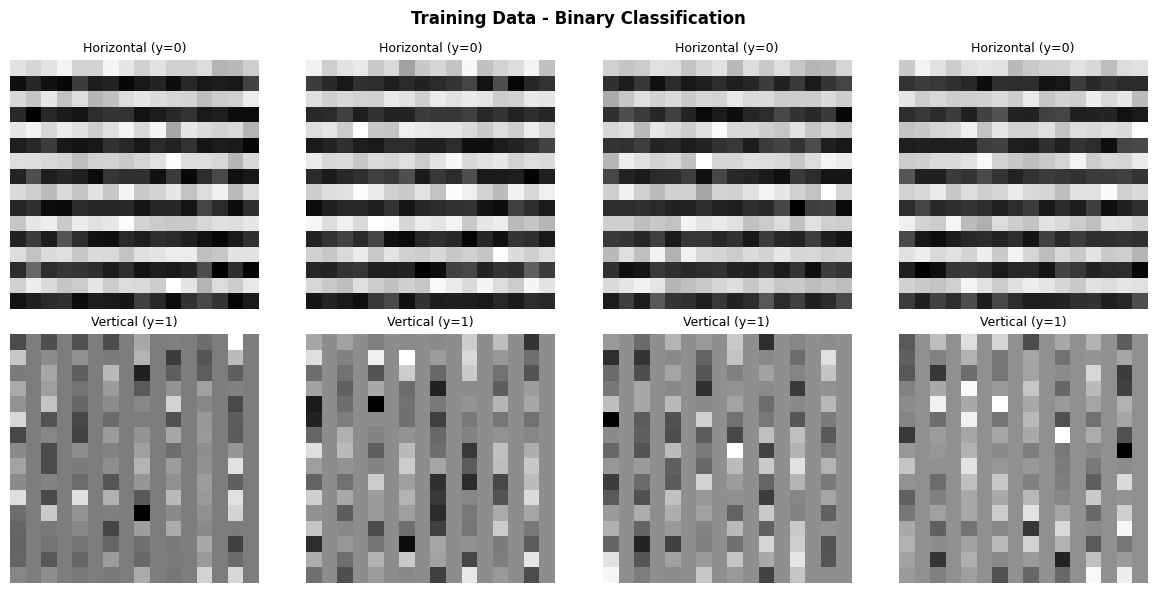

Dataset: 20 images, 16x16 pixels
Class 0 (horizontal): 10
Class 1 (vertical): 10


In [4]:
def make_horizontal(size=16):
    """Create an image with horizontal stripes."""
    img = np.zeros((size, size))
    img[::2, :] = 1.0
    return img

def make_vertical(size=16):
    """Create an image with vertical stripes."""
    img = np.zeros((size, size))
    img[:, ::2] = 1.0
    return img

# Create dataset
np.random.seed(42)
n_samples = 20
X = []
y = []

for _ in range(n_samples // 2):
    noise = np.random.randn(16, 16) * 0.1
    X.append(make_horizontal() + noise)
    y.append(0)  # horizontal = class 0

for _ in range(n_samples // 2):
    noise = np.random.randn(16, 16) * 0.1
    X.append(make_vertical() * noise)
    y.append(1)  # vertical = class 1

X = np.array(X)
y = np.array(y)

# Visualize samples
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(X[i], cmap="gray", interpolation="nearest")
    axes[0, i].set_title(f"Horizontal (y=0)", fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(X[n_samples//2 + i], cmap="gray", interpolation="nearest")
    axes[1, i].set_title(f"Vertical (y=1)", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Training Data - Binary Classification", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("training_data.png", dpi=300)
plt.show()

print(f"Dataset: {X.shape[0]} images, {X.shape[1]}x{X.shape[2]} pixels")
print(f"Class 0 (horizontal): {sum(y==0)}")
print(f"Class 1 (vertical): {sum(y==1)}")

## 3. Simple CNN Architecture
Conv(1 filter) → ReLU → MaxPool → Flatten → Dense → Sigmoid

In [5]:
class SimpleCNN:
    """
    Simple CNN from scratch.
    Architecture: Conv → ReLU → MaxPool → Flatten → Dense → Sigmoid
    """

    def __init__(self):
        np.random.seed(42)
        # One 3x3 filter
        self.kernel = np.random.randn(3, 3) * 0.1
        # After pool: 8x8 = 64 featyres
        self.W = np.random.randn(64, 1) * 0.1
        self.b = np.zeros(1)
        self.losses = []

    def forward(self, x: np.ndarray) -> tuple:
        """Forward pass - returns prediction and cache for backprop."""
        # Conv + ReLU
        conv_out = convolve2d(x, self.kernel)
        relu_out = relu(conv_out)

        # MaxPool (16x16 -> 8x8)
        pool_out = max_pool2d(relu_out, pool_size=2)

        # Flatten
        flat = pool_out.flatten().reshape(-1, 1)

        # Dense + Sigmoid
        z = self.W.T @ flat + self.b
        pred = sigmoid(z)

        cache = (x, conv_out, relu_out, pool_out, flat, z)
        return float(pred), cache

    def train_step(self, x: np.ndarray, y: float,
                   lr: float = 0.01) -> float:
        """Single training step - forward + backward + update."""
        pred, cache = self.forward(x)
        x, conv_out, relu_out, pool_out, flat, z = cache

        # Loss
        loss = -(y * np.log(pred + 1e-8) + (1-y) * np.log(1-pred + 1e-8))

        # Backward - output layer
        dz = pred - y
        dW = flat * dz
        db = dz

        # Backward - flatten (no operation)
        d_flat = self.W * dz
        d_pool = d_flat.reshape(pool_out.shape)

        # Backward - approximate pool gradient
        d_relu = np.repeat(np.repeat(d_pool, 2, axis=0), 2, axis=1)

        # Backward - ReLU
        d_conv = d_relu * relu_derivative(conv_out)

        # Backward - Conv (Gradient w.r.t. kernel)
        pad = 1
        padded_x = np.pad(x, pad)
        dkernel = np.zeros_like(self.kernel)
        for i in range(3):
            for j in range(3):
                dkernel[i, j] = np.sum(
                    padded_x[i:i+16, j:j+16] * d_conv
                )

        # Update
        self.kernel -= lr * dkernel
        self.W -= lr * dW
        self.b -= lr * db

        return float(loss)

    def predict(self, x: np.ndarray) -> int:
        pred, _ = self.forward(x)
        return 1 if pred >= 0.5 else 0

print("SimpleCNN defined.")
print("Architecture: Conv(3x3) → ReLU → MaxPool(2x2) → Dense(64,1) → Sigmoid")

SimpleCNN defined.
Architecture: Conv(3x3) → ReLU → MaxPool(2x2) → Dense(64,1) → Sigmoid
